### Punto 4

In [3]:
!pip install control


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Sofi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
# Modelo del sistema y respuestas impulso/escalón
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
from control.matlab import *   # funciones estilo MATLAB

In [5]:
# Parámetros del sistema
R = 0.5
Cs = 2
Cp = 0.2

# Funciones de transferencia
# X(s) = G1(s)F(s) - G2(s)Fo(s)

# G1(s) = (Cs*Cp*R*s + Cp) / ((R*Cs + R*Cp)*s + 1)
num_G1 = [Cs*Cp*R, Cp]
den_G1 = [R*Cs + R*Cp, 1]
G1 = ctrl.TransferFunction(num_G1, den_G1)

# G2(s) = (Cp*s) / ((R*Cs + R*Cp)*s + 1)
num_G2 = [Cp, 0]
den_G2 = [R*Cs + R*Cp, 1]
G2 = ctrl.TransferFunction(num_G2, den_G2)

print("G1(s) =", G1)
print(" ")
print("G2(s) =", G2)

G1(s) = <TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


0.2 s + 0.2
-----------
 1.1 s + 1

 
G2(s) = <TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


  0.2 s
---------
1.1 s + 1



C:\Users\Sofi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\timeresp.py:1975: UserWarning: System has direct feedthrough: ``D != 0``. The infinite impulse at ``t=0`` does not appear in the output.
Results may be meaningless!
  warnings.warn("System has direct feedthrough: ``D != 0``. The "


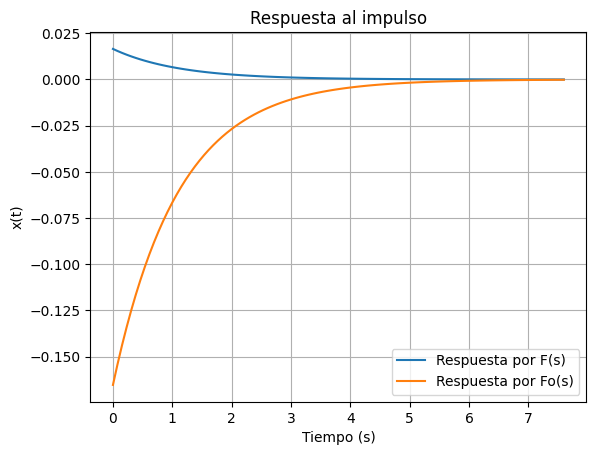

In [6]:
# Respuesta al impulso

t1, y1 = ctrl.impulse_response(G1)

plt.figure(1)
plt.plot(t1, y1, label="Respuesta por F(s)")

t2, y2 = ctrl.impulse_response(G2)
plt.plot(t2, y2, label="Respuesta por Fo(s)")

plt.title("Respuesta al impulso")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.legend()
plt.grid()

plt.show()

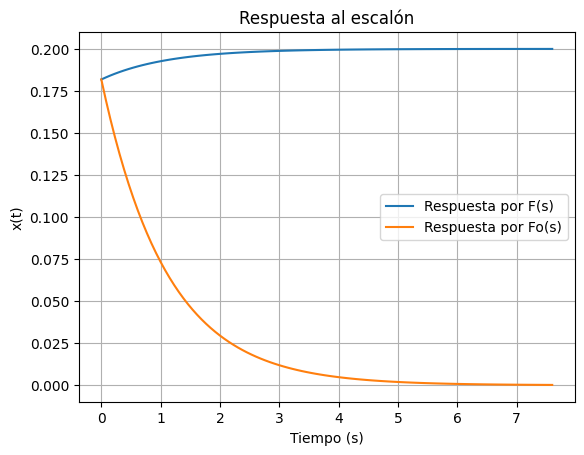

In [7]:
# Respuesta al escalón

t2, y2 = ctrl.step_response(G1)

plt.figure(2)
plt.plot(t2, y2, label="Respuesta por F(s)")

t3, y3 = ctrl.step_response(G2)
plt.plot(t3, y3, label="Respuesta por Fo(s)")

plt.title("Respuesta al escalón")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.legend()
plt.grid()

plt.show()

In [8]:
# Tiempo de muestreo
Ts = 0.1

# Transformada Z (discretización)
G1z = ctrl.c2d(G1, Ts, method='zoh')
G2z = ctrl.c2d(G2, Ts, method='zoh')

print("\nG1(z) =")
print(G1z)

print("\nG2(z) =")
print(G2z)



G1(z) =
<TransferFunction>: sys[0]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


0.1818 z - 0.1644
-----------------
   z - 0.9131

dt = 0.1


G2(z) =
<TransferFunction>: sys[1]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


0.1818 z - 0.1818
-----------------
   z - 0.9131

dt = 0.1



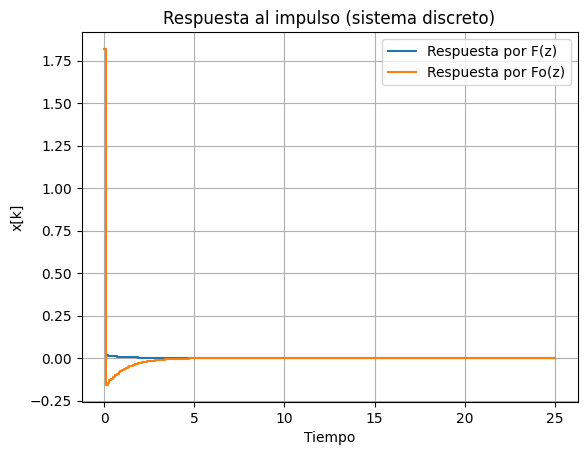

In [9]:
# Respuesta impulso (sistema discreto)

t_imp, y_imp = ctrl.impulse_response(G1z)

plt.figure(3)
plt.step(t_imp, y_imp, where="post", label="Respuesta por F(z)")

t2_imp, y2_imp = ctrl.impulse_response(G2z)
plt.step(t2_imp, y2_imp, where="post", label="Respuesta por Fo(z)")

plt.title("Respuesta al impulso (sistema discreto)")
plt.xlabel("Tiempo")
plt.ylabel("x[k]")
plt.legend()
plt.grid()

plt.show()

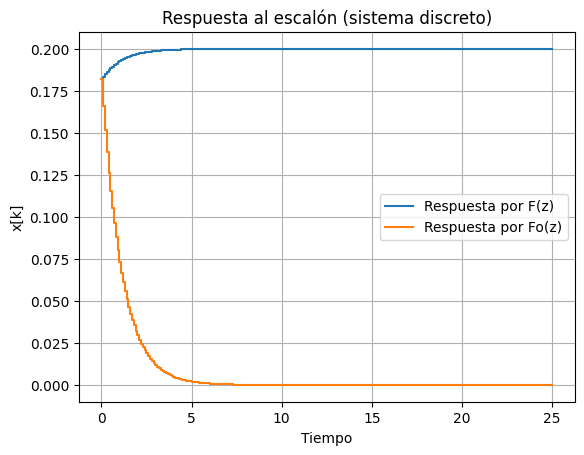

In [10]:
# Respuesta escalón (sistema discreto)

t_step, y_step = ctrl.step_response(G1z)

plt.figure(4)
plt.step(t_step, y_step, where="post", label="Respuesta por F(z)")

t2_step, y2_step = ctrl.step_response(G2z)
plt.step(t2_step, y2_step, where="post", label="Respuesta por Fo(z)")

plt.title("Respuesta al escalón (sistema discreto)")
plt.xlabel("Tiempo")
plt.ylabel("x[k]")
plt.legend()
plt.grid()

plt.show()

### Punto 5

*Considere que la siguiente función de transferencia modela la dinámica simplificada del sistema de control de flujo de un ventilador mecánico.*

 *•	La entrada representa la señal de control aplicada a la válvula proporcional del sistema.*
 
 *•	La salida corresponde al flujo de aire suministrado al paciente.* 
 
 *•	a y b corresponde al último digito de la cedula de cada integrante del grupo y c es la suma de estos últimos dígitos: Reemplazando a = 0, b= 4 y c = 4 se tiene que: $$G(s) = \frac{4}{(s+2)^2}$$*
 

*a)	Determine los polos y ceros del sistema. Simule y grafique la respuesta al escalón unitario, impulso y rampa unitaria en lazo abierto y en lazo cerrado*
 


In [19]:
numP5 = [0, 4] #as + b
denP5 = [1, 4, 4] #s^2 + bs + c

G_5 = tf(numP5, denP5)

print("G (s) =", G_5)

G (s) = <TransferFunction>: sys[25]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


      4
-------------
s^2 + 4 s + 4



Diagrama de polos y ceros

Polos del sistema: [-2.+0.j -2.+0.j]
Ceros del sistema: []

El sistema es estable


C:\Users\Sofi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\pzmap.py:318: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


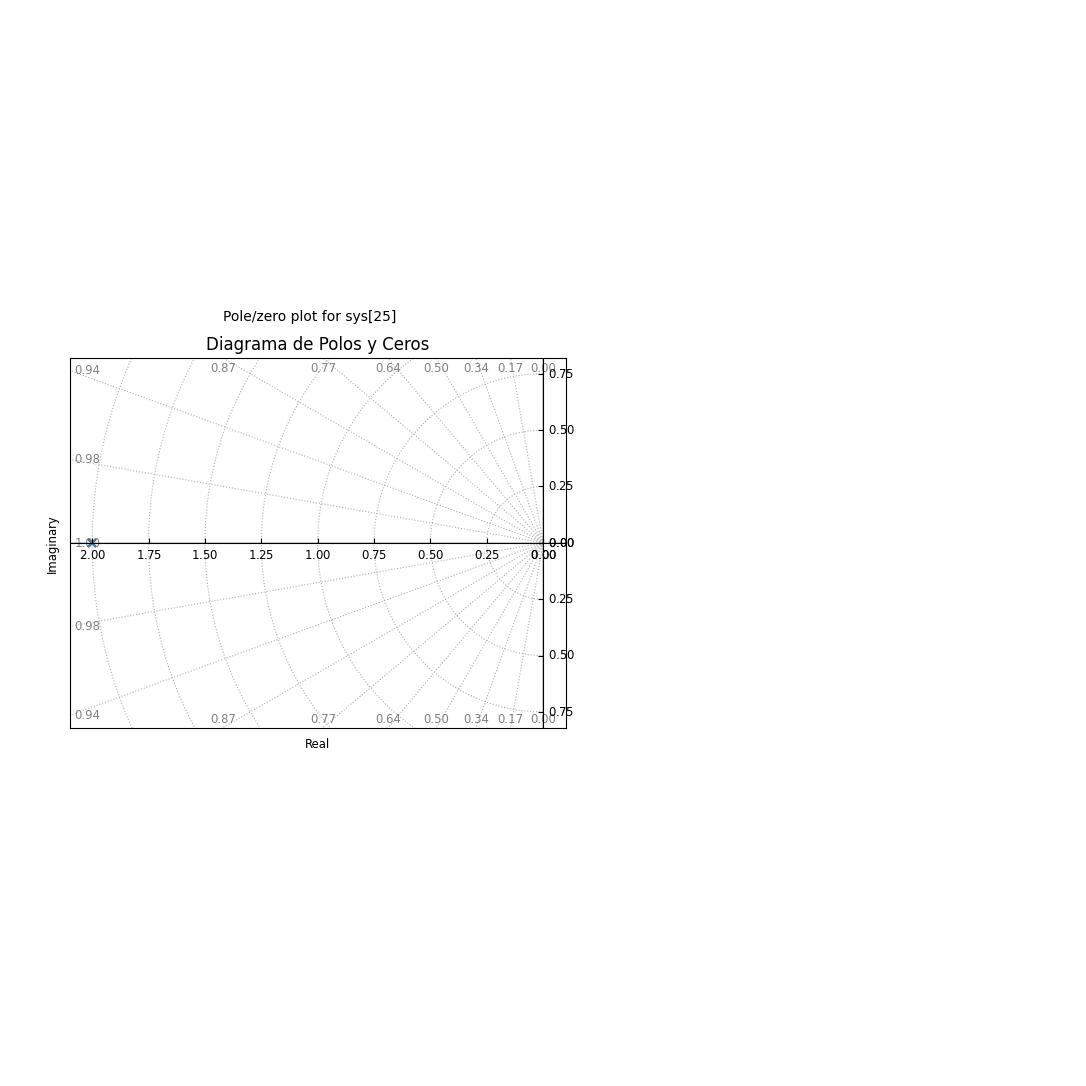

In [23]:
polos = pole(G_5)
ceros = zero(G_5)

print("Polos del sistema:", polos)
print("Ceros del sistema:", ceros)

# estabilidad
if np.all(np.real(polos) < 0):
    print("\nEl sistema es estable")
else:
    print("\nEl sistema es inestable")

# Diagrama de polos y ceros
plt.figure()
pzmap(G_5, plot=True, grid=True)
plt.title("Diagrama de Polos y Ceros")
plt.show()



Respuesta señales básicas en lazo abierto y cerrado

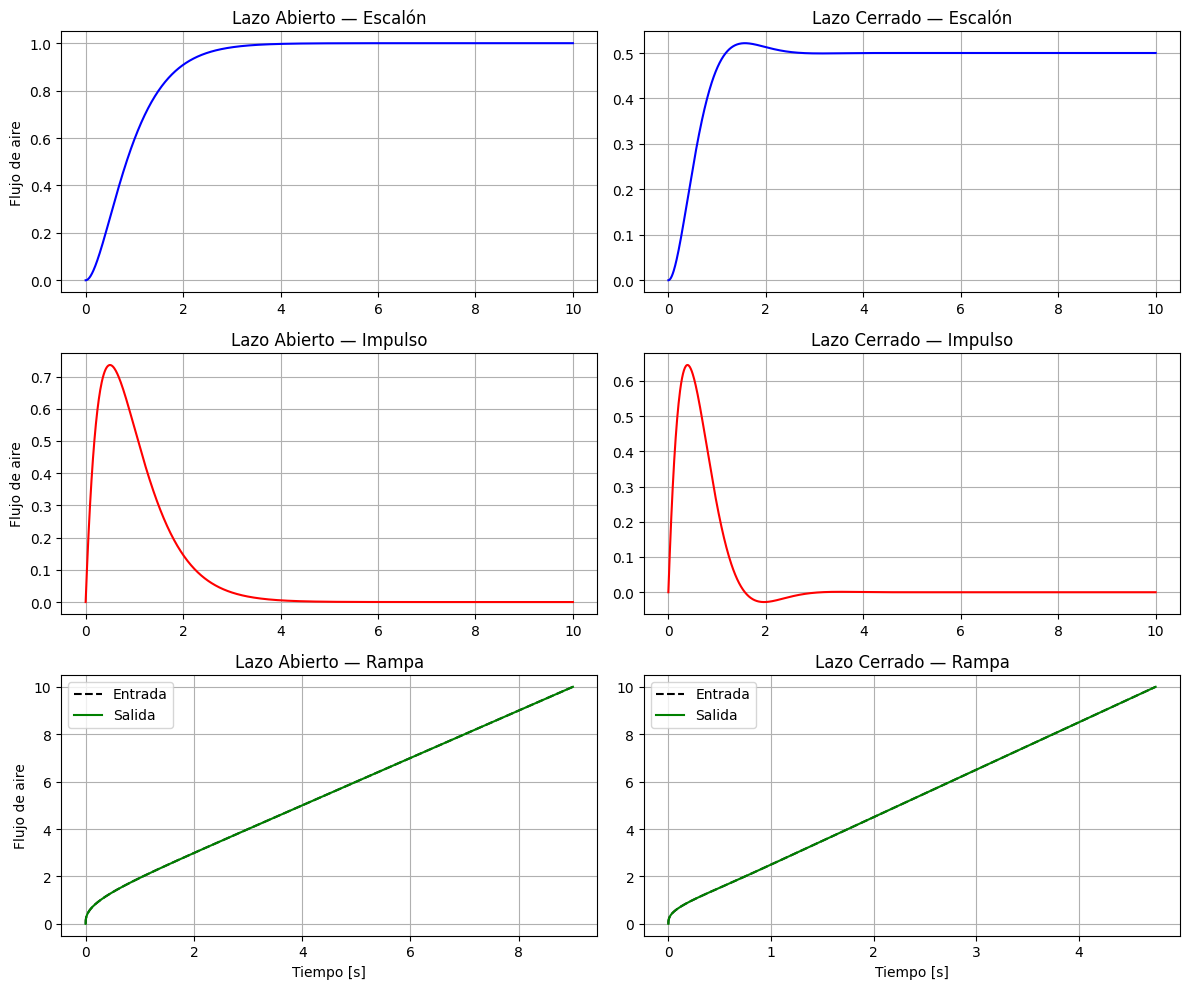

In [ ]:
t = np.linspace(0, 10, 1000)

# Realimentación
G_lc = feedback(G_5, 1)

fig, axs = plt.subplots(3, 2, figsize=(12,10))

#Escalón

# Lazo abierto
y_step_la, t_step_la = step(G_5, T=t)
axs[0,0].plot(t_step_la, y_step_la, 'b')
axs[0,0].set_title("Lazo Abierto — Escalón")
axs[0,0].set_ylabel("Flujo de aire")
axs[0,0].grid(True)

# Lazo cerrado
y_step_lc, t_step_lc = step(G_lc, T=t)
axs[0,1].plot(t_step_lc, y_step_lc, 'b')
axs[0,1].set_title("Lazo Cerrado — Escalón")
axs[0,1].grid(True)

#Impulso

# Lazo abierto
y_imp_la, t_imp_la = impulse(G_5, T=t)
axs[1,0].plot(t_imp_la, y_imp_la, 'r')
axs[1,0].set_title("Lazo Abierto — Impulso")
axs[1,0].set_ylabel("Flujo de aire")
axs[1,0].grid(True)

# Lazo cerrado
y_imp_lc, t_imp_lc = impulse(G_lc, T=t)
axs[1,1].plot(t_imp_lc, y_imp_lc, 'r')
axs[1,1].set_title("Lazo Cerrado — Impulso")
axs[1,1].grid(True)

#Rampa

u_ramp = t

# Lazo abierto
t_ramp_la, y_ramp_la, _ = lsim(G_5, U=u_ramp, T=t)
axs[2,0].plot(t_ramp_la, u_ramp, 'k--', label="Entrada")
axs[2,0].plot(t_ramp_la, y_ramp_la, 'g', label="Salida")
axs[2,0].set_title("Lazo Abierto — Rampa")
axs[2,0].set_xlabel("Tiempo [s]")
axs[2,0].set_ylabel("Flujo de aire")
axs[2,0].legend()
axs[2,0].grid(True)

# Lazo cerrado
t_ramp_lc, y_ramp_lc, _ = lsim(G_lc, U=u_ramp, T=t)
axs[2,1].plot(t_ramp_lc, u_ramp, 'k--', label="Entrada")
axs[2,1].plot(t_ramp_lc, y_ramp_lc, 'g', label="Salida")
axs[2,1].set_title("Lazo Cerrado — Rampa")
axs[2,1].set_xlabel("Tiempo [s]")
axs[2,1].legend()
axs[2,1].grid(True)

plt.tight_layout()
plt.show()

*b)	Obtenga la función de transferencia equivalente en el dominio discreto (Z) para diferentes tiempos de muestreo: T=0.05, 0.1, 0.5, 1seg*

In [ ]:
tiempos_muestreo = [0.05, 0.1, 0.5, 1.0]
Gz_dict = {}

for Ts in tiempos_muestreo:
    Gz = c2d(G_5, Ts, method='zoh') #se obtiene G en el dominio discreto
    print("\nSistema Discreto (ZOH):")
    Gz_dict[Ts] = Gz
    print(Gz)


Sistema Discreto (ZOH):
<TransferFunction>: sys[25]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


0.004679 z + 0.004377
---------------------
z^2 - 1.81 z + 0.8187

dt = 0.05


Sistema Discreto (ZOH):
<TransferFunction>: sys[25]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


 0.01752 z + 0.01534
----------------------
z^2 - 1.637 z + 0.6703

dt = 0.1


Sistema Discreto (ZOH):
<TransferFunction>: sys[25]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


   0.2642 z + 0.1353
-----------------------
z^2 - 0.7358 z + 0.1353

dt = 0.5


Sistema Discreto (ZOH):
<TransferFunction>: sys[25]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


    0.594 z + 0.1537
------------------------
z^2 - 0.2707 z + 0.01832

dt = 1.0



*c)	Para cada sistema discreto obtenido, simule y grafique la respuesta al escalón unitario, rampa y al impulso unitario en lazo abierto y en lazo cerrado*

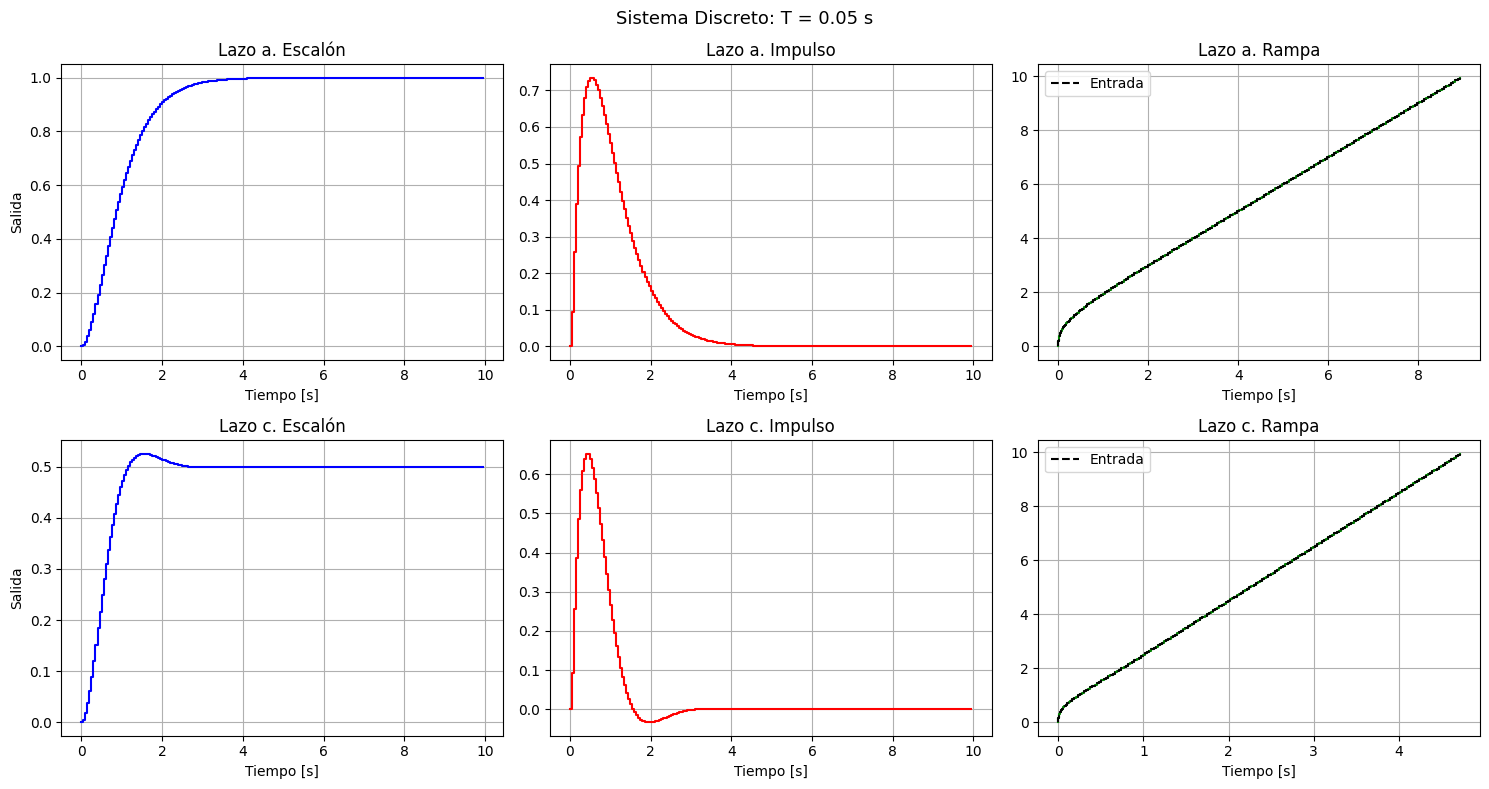

In [ ]:

Ts = 0.05
Gz    = Gz_dict[Ts]
Gz_cl = feedback(Gz, 1)
t_d   = np.arange(0, 10, Ts)
u_r   = t_d   # para la rampa

y_s_la, t_s_la = step(Gz,    T=t_d)
y_s_lc, t_s_lc = step(Gz_cl, T=t_d)
y_i_la, t_i_la = impulse(Gz,    T=t_d)
y_i_lc, t_i_lc = impulse(Gz_cl, T=t_d)
t_r_la, y_r_la, _ = lsim(Gz,    U=u_r, T=t_d)
t_r_lc, y_r_lc, _ = lsim(Gz_cl, U=u_r, T=t_d)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"Sistema Discreto: T = {Ts} s", fontsize=13)

axes[0,0].step(t_s_la, y_s_la, 'b', where='post'); axes[0,0].set_title("Lazo a. Escalón"); axes[0,0].grid(True); axes[0,0].set_xlabel("Tiempo [s]"); axes[0,0].set_ylabel("Salida")
axes[0,1].step(t_i_la, y_i_la, 'r', where='post'); axes[0,1].set_title("Lazo a. Impulso"); axes[0,1].grid(True); axes[0,1].set_xlabel("Tiempo [s]")
axes[0,2].step(t_r_la, y_r_la, 'g', where='post'); axes[0,2].step(t_r_la, u_r, 'k--', where='post', label='Entrada'); axes[0,2].set_title("Lazo a. Rampa"); axes[0,2].grid(True); axes[0,2].set_xlabel("Tiempo [s]"); axes[0,2].legend()
axes[1,0].step(t_s_lc, y_s_lc, 'b', where='post'); axes[1,0].set_title("Lazo c. Escalón"); axes[1,0].grid(True); axes[1,0].set_xlabel("Tiempo [s]"); axes[1,0].set_ylabel("Salida")
axes[1,1].step(t_i_lc, y_i_lc, 'r', where='post'); axes[1,1].set_title("Lazo c. Impulso"); axes[1,1].grid(True); axes[1,1].set_xlabel("Tiempo [s]")
axes[1,2].step(t_r_lc, y_r_lc, 'g', where='post'); axes[1,2].step(t_r_lc, u_r, 'k--', where='post', label='Entrada'); axes[1,2].set_title("Lazo c. Rampa"); axes[1,2].grid(True); axes[1,2].set_xlabel("Tiempo [s]"); axes[1,2].legend()

plt.tight_layout()
plt.show()

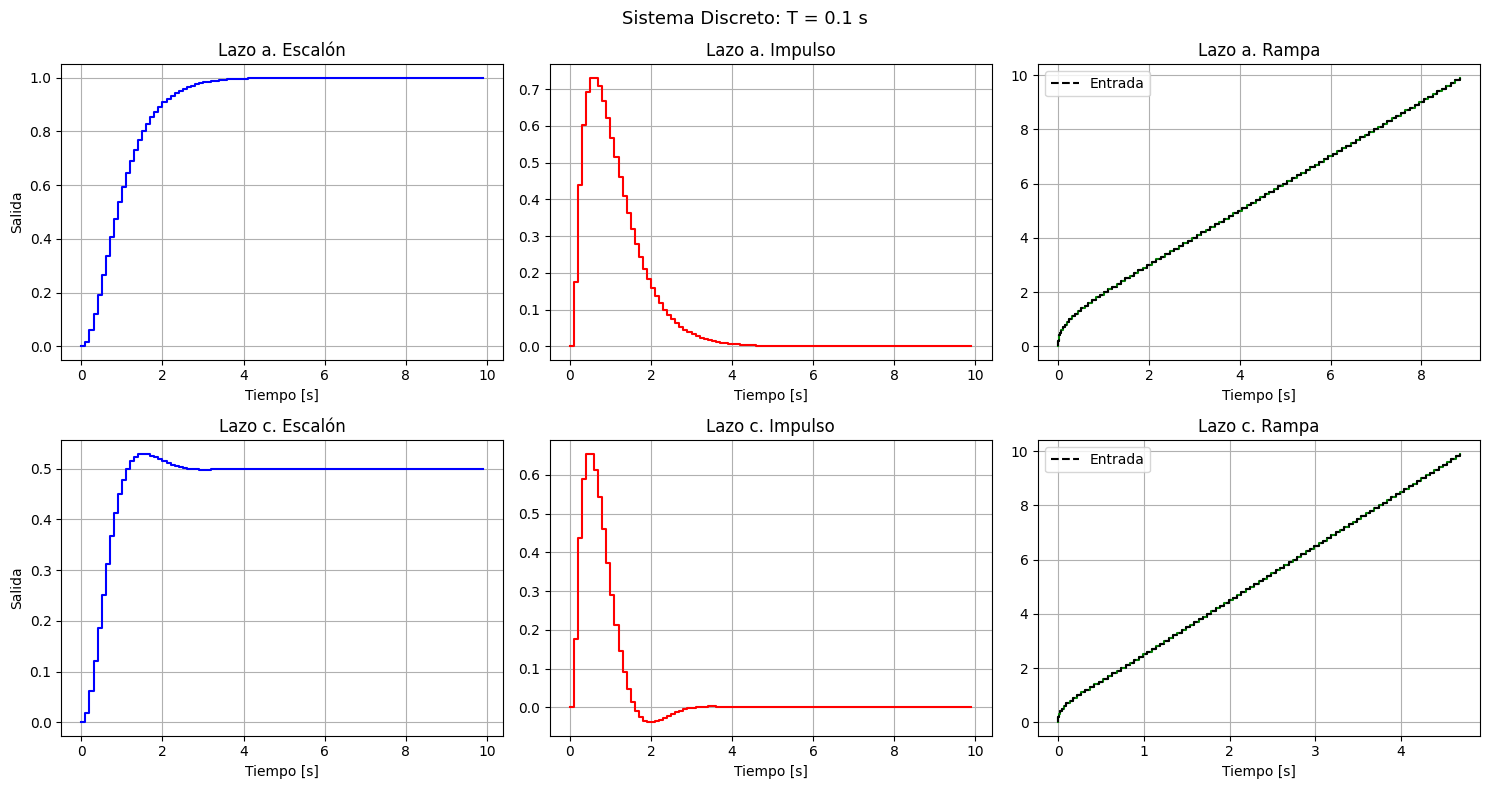

In [55]:
Ts = 0.1
Gz    = Gz_dict[Ts]
Gz_cl = feedback(Gz, 1)
t_d   = np.arange(0, 10, Ts)
u_r   = t_d

y_s_la, t_s_la = step(Gz,    T=t_d)
y_s_lc, t_s_lc = step(Gz_cl, T=t_d)
y_i_la, t_i_la = impulse(Gz,    T=t_d)
y_i_lc, t_i_lc = impulse(Gz_cl, T=t_d)
t_r_la, y_r_la, _ = lsim(Gz,    U=u_r, T=t_d)
t_r_lc, y_r_lc, _ = lsim(Gz_cl, U=u_r, T=t_d)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"Sistema Discreto: T = {Ts} s", fontsize=13)

axes[0,0].step(t_s_la, y_s_la, 'b', where='post'); axes[0,0].set_title("Lazo a. Escalón"); axes[0,0].grid(True); axes[0,0].set_xlabel("Tiempo [s]"); axes[0,0].set_ylabel("Salida")
axes[0,1].step(t_i_la, y_i_la, 'r', where='post'); axes[0,1].set_title("Lazo a. Impulso"); axes[0,1].grid(True); axes[0,1].set_xlabel("Tiempo [s]")
axes[0,2].step(t_r_la, y_r_la, 'g', where='post'); axes[0,2].step(t_r_la, u_r, 'k--', where='post', label='Entrada'); axes[0,2].set_title("Lazo a. Rampa"); axes[0,2].grid(True); axes[0,2].set_xlabel("Tiempo [s]"); axes[0,2].legend()
axes[1,0].step(t_s_lc, y_s_lc, 'b', where='post'); axes[1,0].set_title("Lazo c. Escalón"); axes[1,0].grid(True); axes[1,0].set_xlabel("Tiempo [s]"); axes[1,0].set_ylabel("Salida")
axes[1,1].step(t_i_lc, y_i_lc, 'r', where='post'); axes[1,1].set_title("Lazo c. Impulso"); axes[1,1].grid(True); axes[1,1].set_xlabel("Tiempo [s]")
axes[1,2].step(t_r_lc, y_r_lc, 'g', where='post'); axes[1,2].step(t_r_lc, u_r, 'k--', where='post', label='Entrada'); axes[1,2].set_title("Lazo c. Rampa"); axes[1,2].grid(True); axes[1,2].set_xlabel("Tiempo [s]"); axes[1,2].legend()
plt.tight_layout()
plt.show()

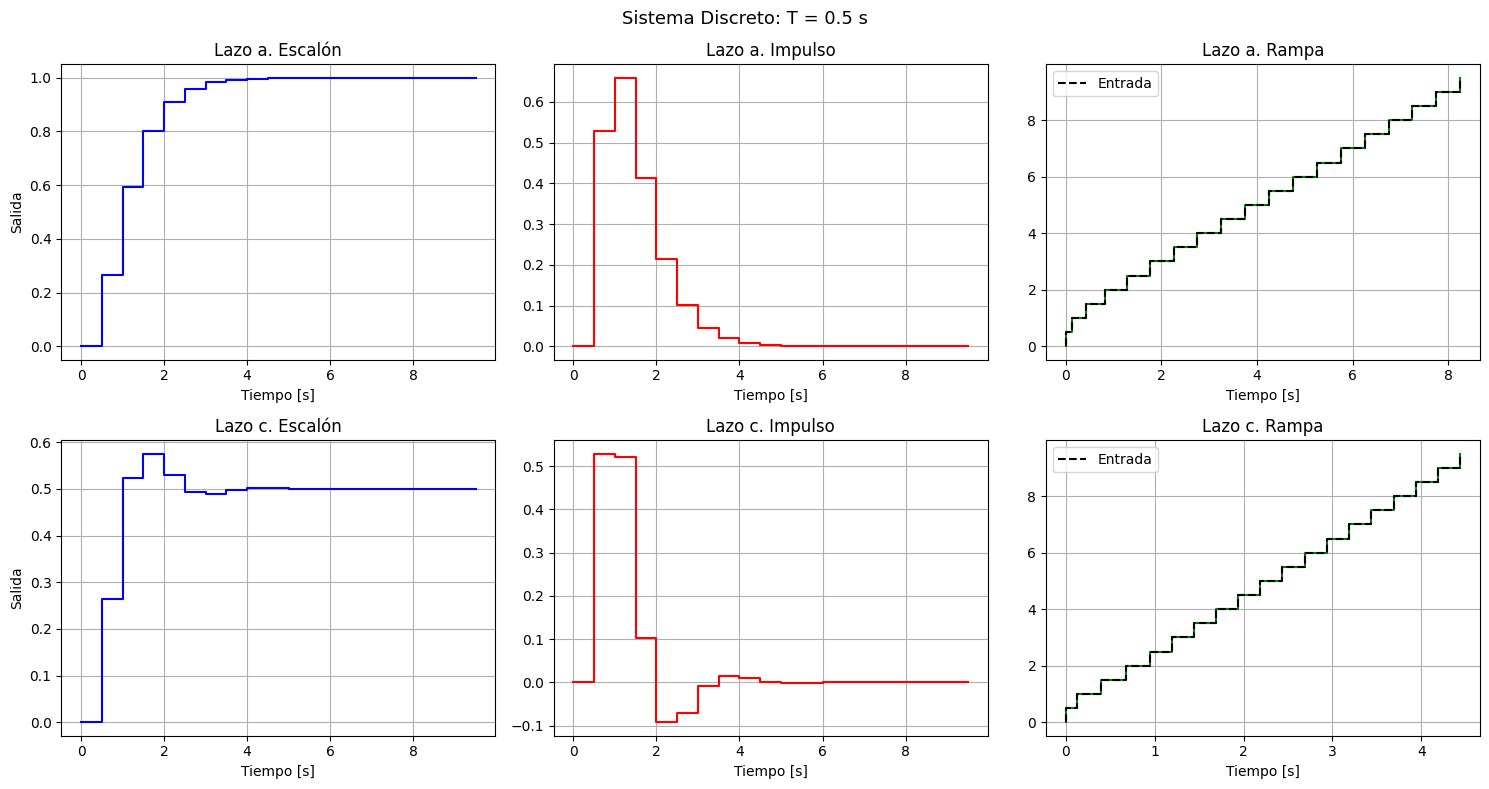

In [56]:
Ts = 0.5
Gz    = Gz_dict[Ts]
Gz_cl = feedback(Gz, 1)
t_d   = np.arange(0, 10, Ts)
u_r   = t_d

y_s_la, t_s_la = step(Gz,    T=t_d)
y_s_lc, t_s_lc = step(Gz_cl, T=t_d)
y_i_la, t_i_la = impulse(Gz,    T=t_d)
y_i_lc, t_i_lc = impulse(Gz_cl, T=t_d)
t_r_la, y_r_la, _ = lsim(Gz,    U=u_r, T=t_d)
t_r_lc, y_r_lc, _ = lsim(Gz_cl, U=u_r, T=t_d)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"Sistema Discreto: T = {Ts} s", fontsize=13)

axes[0,0].step(t_s_la, y_s_la, 'b', where='post'); axes[0,0].set_title("Lazo a. Escalón"); axes[0,0].grid(True); axes[0,0].set_xlabel("Tiempo [s]"); axes[0,0].set_ylabel("Salida")
axes[0,1].step(t_i_la, y_i_la, 'r', where='post'); axes[0,1].set_title("Lazo a. Impulso"); axes[0,1].grid(True); axes[0,1].set_xlabel("Tiempo [s]")
axes[0,2].step(t_r_la, y_r_la, 'g', where='post'); axes[0,2].step(t_r_la, u_r, 'k--', where='post', label='Entrada'); axes[0,2].set_title("Lazo a. Rampa"); axes[0,2].grid(True); axes[0,2].set_xlabel("Tiempo [s]"); axes[0,2].legend()
axes[1,0].step(t_s_lc, y_s_lc, 'b', where='post'); axes[1,0].set_title("Lazo c. Escalón"); axes[1,0].grid(True); axes[1,0].set_xlabel("Tiempo [s]"); axes[1,0].set_ylabel("Salida")
axes[1,1].step(t_i_lc, y_i_lc, 'r', where='post'); axes[1,1].set_title("Lazo c. Impulso"); axes[1,1].grid(True); axes[1,1].set_xlabel("Tiempo [s]")
axes[1,2].step(t_r_lc, y_r_lc, 'g', where='post'); axes[1,2].step(t_r_lc, u_r, 'k--', where='post', label='Entrada'); axes[1,2].set_title("Lazo c. Rampa"); axes[1,2].grid(True); axes[1,2].set_xlabel("Tiempo [s]"); axes[1,2].legend()
plt.tight_layout()
plt.show()


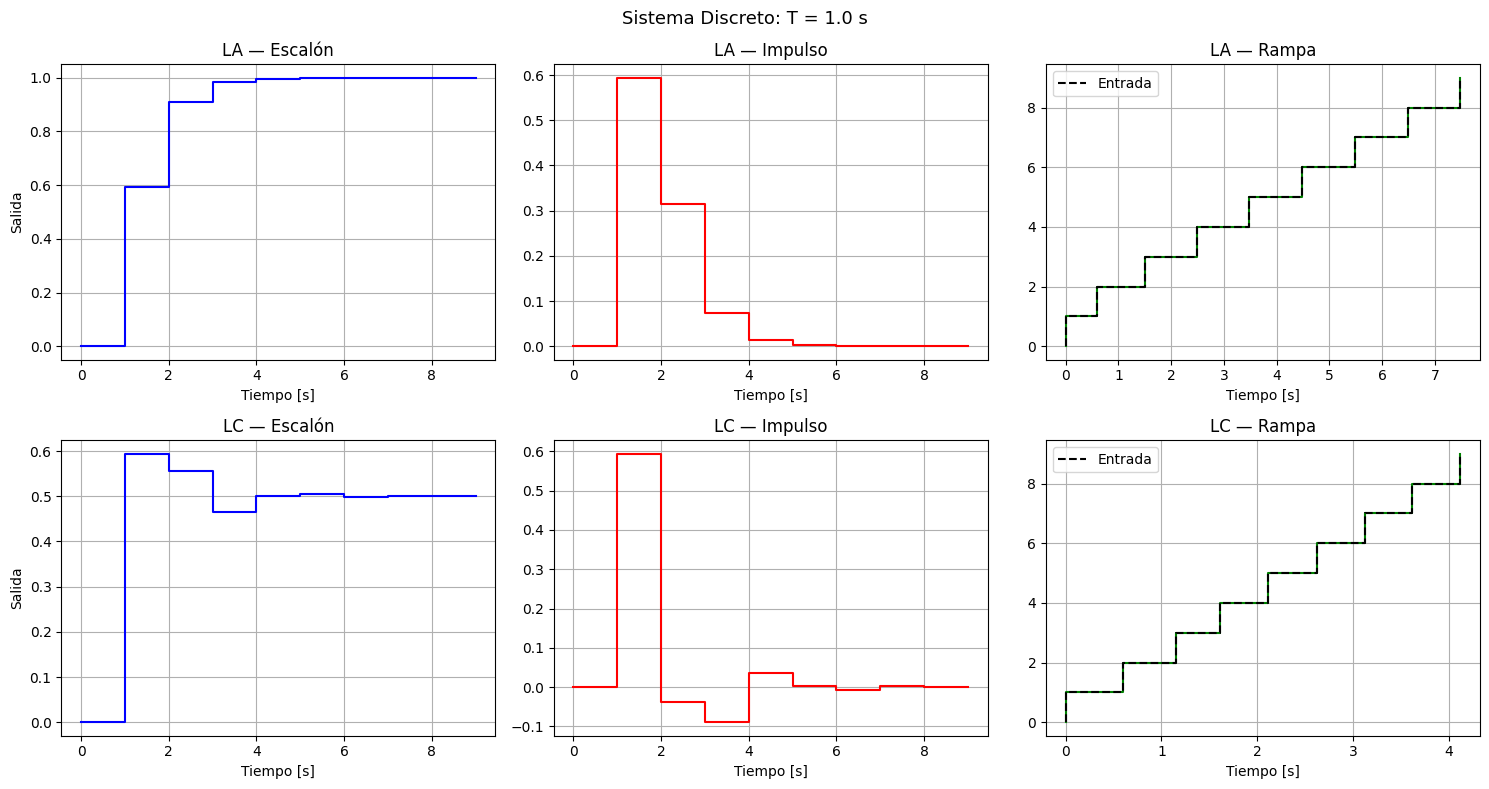

In [57]:
Ts = 1.0
Gz    = Gz_dict[Ts]
Gz_cl = feedback(Gz, 1)
t_d   = np.arange(0, 10, Ts)
u_r   = t_d

y_s_la, t_s_la = step(Gz,    T=t_d)
y_s_lc, t_s_lc = step(Gz_cl, T=t_d)
y_i_la, t_i_la = impulse(Gz,    T=t_d)
y_i_lc, t_i_lc = impulse(Gz_cl, T=t_d)
t_r_la, y_r_la, _ = lsim(Gz,    U=u_r, T=t_d)
t_r_lc, y_r_lc, _ = lsim(Gz_cl, U=u_r, T=t_d)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"Sistema Discreto: T = {Ts} s", fontsize=13)

axes[0,0].step(t_s_la, y_s_la, 'b', where='post'); axes[0,0].set_title("LA — Escalón"); axes[0,0].grid(True); axes[0,0].set_xlabel("Tiempo [s]"); axes[0,0].set_ylabel("Salida")
axes[0,1].step(t_i_la, y_i_la, 'r', where='post'); axes[0,1].set_title("LA — Impulso"); axes[0,1].grid(True); axes[0,1].set_xlabel("Tiempo [s]")
axes[0,2].step(t_r_la, y_r_la, 'g', where='post'); axes[0,2].step(t_r_la, u_r, 'k--', where='post', label='Entrada'); axes[0,2].set_title("LA — Rampa"); axes[0,2].grid(True); axes[0,2].set_xlabel("Tiempo [s]"); axes[0,2].legend()
axes[1,0].step(t_s_lc, y_s_lc, 'b', where='post'); axes[1,0].set_title("LC — Escalón"); axes[1,0].grid(True); axes[1,0].set_xlabel("Tiempo [s]"); axes[1,0].set_ylabel("Salida")
axes[1,1].step(t_i_lc, y_i_lc, 'r', where='post'); axes[1,1].set_title("LC — Impulso"); axes[1,1].grid(True); axes[1,1].set_xlabel("Tiempo [s]")
axes[1,2].step(t_r_lc, y_r_lc, 'g', where='post'); axes[1,2].step(t_r_lc, u_r, 'k--', where='post', label='Entrada'); axes[1,2].set_title("LC — Rampa"); axes[1,2].grid(True); axes[1,2].set_xlabel("Tiempo [s]"); axes[1,2].legend()

plt.tight_layout()
plt.show()

Valor de T que mejor representa el sistema discreto mediante el cálculo de MSE

In [64]:
# Referencia continua
t = np.linspace(0, 10, 1000)
y_cont_la, t_cont_la = step(G_5, T=t)

# MSE por tiempo de muestreo
print(f"{'T (s)':<10} {'MSE':<20}")

for Ts in tiempos_muestreo:
    t_d = np.arange(0, 10, Ts)
    y_d, t_d_s = step(Gz_dict[Ts], T=t_d)
    y_ref = np.interp(t_d_s, t_cont_la, y_cont_la)
    mse = np.mean((y_d - y_ref)**2)
    print(f"{Ts:<10} {mse:<20.6e}")

T (s)      MSE                 
0.05       9.159721e-13        
0.1        9.157186e-13        
0.5        8.482156e-13        
1.0        9.364850e-13        
